<a href="https://colab.research.google.com/github/haridevsreebhavan/AI-Training-/blob/main/Assignments/Assignment_4/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
from datasets import load_dataset

dataset = load_dataset("imdb", split="train[:2000]")
texts = dataset["text"]

In [54]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

cleaned_texts = [clean_text(t) for t in texts]

In [55]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

tokens = [word_tokenize(t) for t in cleaned_texts]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [56]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

tokens_no_stop = [[w for w in doc if w not in stop_words] for doc in tokens]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [57]:
import spacy
nlp = spacy.load("en_core_web_sm")

def lemmatize(text):
    doc = nlp(" ".join(text))
    return [token.lemma_ for token in doc]

lemmatized = [lemmatize(doc) for doc in tokens_no_stop]

In [58]:
from collections import Counter

all_words = [word for doc in lemmatized for word in doc]
vocab = Counter(all_words)

print("Vocabulary size:", len(vocab))

Vocabulary size: 24572


In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts_joined = [" ".join(doc) for doc in lemmatized]

tfidf = TfidfVectorizer(max_features=5000)
tfidf_vectors = tfidf.fit_transform(texts_joined)

In [60]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)
bow_vectors = bow.fit_transform(texts_joined)

In [61]:
!pip install gensim
from gensim.models import Word2Vec

w2v_model = Word2Vec(sentences=lemmatized, vector_size=100, window=5, min_count=2)

In [62]:
import numpy as np

def sentence_embedding(doc):
    vectors = []
    weights = []

    for word in doc:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])
            weights.append(vocab[word])

    if vectors:
        return np.average(vectors, axis=0, weights=weights)
    else:
        return np.zeros(100)

In [63]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar(query, top_n=5):
    q = clean_text(query)

    q_tokens = word_tokenize(q)
    q_tokens = [w for w in q_tokens if w not in stop_words]
    q_lem = lemmatize(q_tokens)

    q_vec = sentence_embedding(q_lem).reshape(1, -1)

    sims = cosine_similarity(q_vec, sentence_vectors)[0]
    top_idx = sims.argsort()[-top_n:][::-1]

    return [(texts[int(i)], float(sims[int(i)])) for i in top_idx]

In [64]:
results = find_similar("This movie was amazing and emotional")

for text, score in results:
    print("Score:", score)
    print("Text:", text[:150])
    print("-" * 50)

Score: 0.9881573511938451
Text: This was one of the worst movies i have ever seen. The plot is awful, and the acting is worse. The jokes that are attempted absolutley suck. Don't bot
--------------------------------------------------
Score: 0.9858410528189498
Text: This is definitely the worst movie Adam's ever done but at this point in his life, he was just happy to have a movie. There are 3 or 4 laughs in it bu
--------------------------------------------------
Score: 0.9842778551881081
Text: This must be one of the worst Swedish movies ever made. <br /><br />It is embarrassing that such a bad script was allowed to become a movie and shown 
--------------------------------------------------
Score: 0.9841781939167743
Text: This has to be the worst movie I have seen. Madsen fans don't be drawn into this like I was. He is only in it for a maximum of five minutes. This movi
--------------------------------------------------
Score: 0.9841562974387958
Text: I've seen this film because I ha

An end-to-end NLP pipeline was developed to preprocess text and enable semantic similarity search. While the system successfully identifies contextually similar reviews, it does not always capture sentiment differences due to limitations of Word2Vec embeddings. Overall, the pipeline effectively demonstrates the process of converting raw text into meaningful representations for real-world applications.


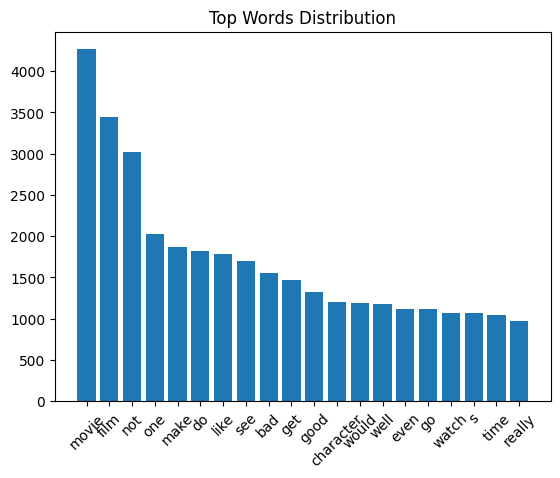

In [65]:
import matplotlib.pyplot as plt


common_words = vocab.most_common(20)
words, counts = zip(*common_words)

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Words Distribution")
plt.show()